In [ ]:
!pip install --quiet rasterio
!pip install --quiet --upgrade gdown

In [ ]:
!gdown https://drive.google.com/uc?id=1Qw96Drmk2jzBYSED0YPEUyuc2DnBechl

In [ ]:
import os
from glob import glob
public_folder = "." # because we downloaded these locally
files_to_extract = sorted(glob(os.path.join(public_folder,"*.zip")))
print("All:",files_to_extract)

In [ ]:
import zipfile
from tqdm import tqdm

dataset_folder = "./datasets"
os.makedirs(dataset_folder, exist_ok=True)

for zip_files in tqdm(files_to_extract):
  with zipfile.ZipFile(zip_files, "r") as zip_ref:
    zip_ref.extractall(dataset_folder)
    zip_ref.close()

In [ ]:
!rm *.zip

In [ ]:
folders_in_test = sorted(glob(os.path.join(dataset_folder,"STARCOP_test/*")))
folders_in_test = [f for f in folders_in_test if ".csv" not in f]

print("We have", len(folders_in_test), "folders in the test set.")

folders_in_train_easy = sorted(glob(os.path.join(dataset_folder,"STARCOP_train_easy/*")))
folders_in_train_easy = [f for f in folders_in_train_easy if ".csv" not in f]
print("And we have", len(folders_in_train_easy), "folders in the train_easy subset.")

folders_in_mini = sorted(glob(os.path.join(dataset_folder,"STARCOP_mini/*")))
folders_in_mini = [f for f in folders_in_mini if ".csv" not in f]
print("And we have", len(folders_in_mini), "folders in the mini subset.")

print("\n--\n")

print("Each folder has these files:")
!ls {folders_in_mini[0]}

In [ ]:
print("These are the available csv files:")
!ls datasets/*/*.csv

In [1]:
visualise_folder = "datasets/STARCOP_mini" # "datasets/STARCOP_test" # "datasets/STARCOP_train_easy"

csv_file = "datasets/STARCOP_mini/test_mini10.csv"

In [ ]:
import rasterio.plot as rstplt
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from mpl_toolkits.axes_grid1 import make_axes_locatable

def hide_all_ticks(ax, hide_border=False):
    # hide all ticks
    ax.xaxis.set_tick_params(labelbottom=False)
    ax.yaxis.set_tick_params(labelleft=False)
    ax.set_xticks([])
    ax.set_yticks([])

    #hide border
    if hide_border: ax.axis('off')

def colorbar_next_to(im, ax, size='5%',pad=0.05):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size=size, pad=pad)
    plt.gcf().colorbar(im, cax=cax, orientation='vertical')

def maintain_same_sizes(im, ax, size='5%',pad=0.05):
    # creates and deletes a fake colorbar - to maintain the same plot sizes
    colorbar_next_to(im, ax, size=size, pad=pad)
    fig.delaxes(fig.axes[-1])

In [16]:
import pandas as pd
csv_file = "train_easy.csv"
df = pd.read_csv(csv_file)
df = df.sort_values(by=['qplume'], ascending=False)

In [13]:
df

,id,candidate_id,qplume,name,folder,date,datetime,window_col_off,window_row_off,window_width,window_height,subset,difficulty,label_path,has_plume,window_labels
286,ang20191011t165345_r4367_c196_w151_h151,ang20191011t165345-1,11239.539700,ang20191011t165345,/AVIRISNG/Permian2019/ang20191011t165345_r4367...,2019-10-11,2019-10-11 16:53:45+00:00,0,0,512,512,train,easy,gs://starcop/Permian/permian_2019_official/ang...,True,"Window(col_off=-180, row_off=-180, width=512, ..."
287,ang20190924t183641_r14137_c154_w151_h151,ang20190924t183641-4,11164.897300,ang20190924t183641,/AVIRISNG/Permian2019/ang20190924t183641_r1413...,2019-09-24,2019-09-24 18:36:41+00:00,0,0,512,512,train,easy,gs://starcop/Permian/permian_2019_official/ang...,True,"Window(col_off=-180, row_off=-180, width=512, ..."
288,ang20191008t151045_r5097_c477_w151_h151,ang20191008t151045-12,6924.176730,ang20191008t151045,/AVIRISNG/Permian2019/ang20191008t151045_r5097...,2019-10-08,2019-10-08 15:10:45+00:00,0,0,512,512,train,easy,gs://starcop/Permian/permian_2019_official/ang...,True,"Window(col_off=-180, row_off=-180, width=512, ..."
289,ang20191010t155034_r16931_c325_w151_h151,ang20191010t155034-A,6166.409548,ang20191010t155034,/AVIRISNG/Permian2019/ang20191010t155034_r1693...,2019-10-10,2019-10-10 15:50:34+00:00,0,0,512,512,train,easy,gs://starcop/Permian/permian_2019_official/ang...,True,"Window(col_off=-180, row_off=-180, width=512, ..."
290,ang20191005t210402_r9366_c472_w151_h151,ang20191005t210402-10,5784.074120,ang20191005t210402,/AVIRISNG/Permian2019/ang20191005t210402_r9366...,2019-10-05,2019-10-05 21:04:02+00:00,0,0,512,512,train,easy,gs://starcop/Permian/permian_2019_official/ang...,True,"Window(col_off=-180, row_off=-180, width=512, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,ang20191023t142135_r9728_c256_w512_h512,NaN,0.000000,ang20191023t142135,/AVIRISNG/Permian2019/ang20191023t142135_r9728...,2019-10-23,2019-10-23 14:21:35+00:00,0,0,512,512,train,hard,NaN,False,"Window(col_off=0, row_off=0, width=512, height..."
5,ang20190923t183439_r0_c0_w512_h512,NaN,0.000000,ang20190923t183439,/AVIRISNG/Permian2019/ang20190923t183439_r0_c0...,2019-09-23,2019-09-23 18:34:39+00:00,0,0,512,512,train,hard,NaN,False,"Window(col_off=0, row_off=0, width=512, height..."
14,ang20190926t152524_r0_c256_w512_h512,NaN,0.000000,ang20190926t152524,/AVIRISNG/Permian2019/ang20190926t152524_r0_c2...,2019-09-26,2019-09-26 15:25:24+00:00,0,0,512,512,train,hard,NaN,False,"Window(col_off=0, row_off=0, width=512, height..."
21,ang20190926t171159_r7168_c256_w512_h512,NaN,0.000000,ang20190926t171159,/AVIRISNG/Permian2019/ang20190926t171159_r7168...,2019-09-26,2019-09-26 17:11:59+00:00,0,0,512,512,train,hard,NaN,False,"Window(col_off=0, row_off=0, width=512, height..."


In [ ]:
df['subset'].unique()

Stratifying qplume into 10 bins


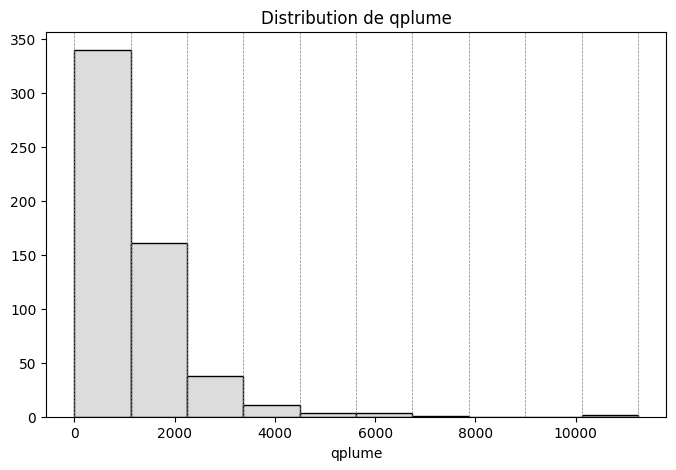

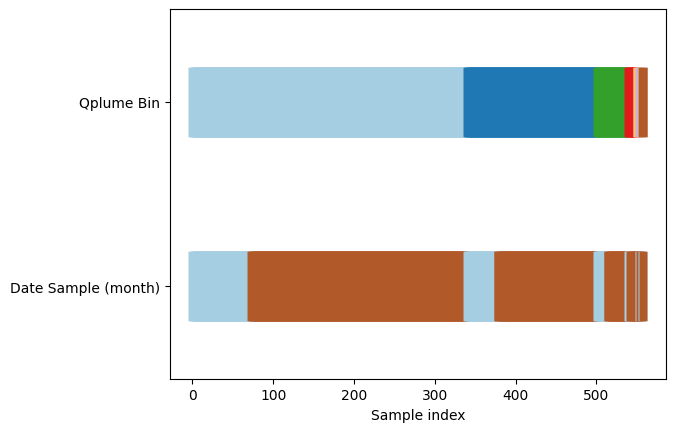

In [17]:
import matplotlib.pyplot as plt
cmap_data = plt.cm.Paired
cmap_cv = plt.cm.coolwarm
from sklearn.preprocessing import LabelEncoder
import numpy as np
import joypy

num_bins = min(10, int(np.floor(1 + np.log2(len(df)))))
print(f"Stratifying qplume into {num_bins} bins")

df['total_bin'] = pd.cut(
    df['qplume'], 
    bins=num_bins, 
    labels=False,
    duplicates='drop'  # Remove duplicate edges
)



plt.figure(figsize=(8, 5))
# plot the distribution of qplume
plt.hist(df['qplume'].dropna(), bins=num_bins,
         color=cmap_cv(0.5), edgecolor='black')
# optional: draw the bin edges if you like
bin_edges = np.linspace(df['qplume'].min(), df['qplume'].max(), num_bins+1)
for e in bin_edges:
    plt.axvline(e, color='gray', linestyle='--', linewidth=0.5)

plt.xlabel(f"qplume")
plt.title(f"Distribution de qplume")
plt.show()




def visualize_groups(classes, groups, name):
    # Visualize dataset groups
    
    fig, ax = plt.subplots()
    ax.scatter(
        range(len(groups)),
        [0.5] * len(groups),
        c=groups,
        marker="_",
        lw=50,
        cmap=cmap_data,
    )
    ax.scatter(
        range(len(groups)),
        [3.5] * len(groups),
        c=classes,
        marker="_",
        lw=50,
        cmap=cmap_data,
    )
    ax.set(
        ylim=[-1, 5],
        yticks=[0.5, 3.5],
        yticklabels=["Date Sample (month)", "Qplume Bin"],
        xlabel="Sample index",
    )



df = df.sort_values("total_bin").reset_index(drop=True)
df["date"] = pd.to_datetime(
    df["date"]
)

df["date"] = df["date"].dt.month
state_order = sorted(df["total_bin"].unique())

train_sorted = (
    df
    .assign(
        total_bin=pd.Categorical(
            df["total_bin"],
            categories=state_order,
            ordered=True
        )
    )
    .sort_values(["total_bin", "date"])
    .reset_index(drop=True)
)


visualize_groups(
    classes=train_sorted["total_bin"].cat.codes,
    groups=train_sorted["date"].astype("category").cat.codes,
    name="Ordered by bin → Date"
)

In [18]:
print('nbr bins:', num_bins)

nbr bins: 10


In [ ]:
size_read = 300
show_first = 10
fig_size_multiplier = 4

for idx, event_id in enumerate(list(df["id"])):
  ft = os.path.join(visualise_folder, event_id)
  # Typical input for our hyperspectral model: RGB + mag1c
  aviris_r = os.path.join(ft, "TOA_AVIRIS_640nm.tif")
  aviris_g = os.path.join(ft, "TOA_AVIRIS_550nm.tif")
  aviris_b = os.path.join(ft, "TOA_AVIRIS_460nm.tif")
  magic_path = os.path.join(ft, "mag1c.tif")
  # Ground truth:
  gt_path = os.path.join(ft, "labelbinary.tif")
  n_plots = 3

  with rasterio.open(gt_path) as src:
    width = src.width
    height = src.height

    # Compute shape to read to from pyramids and speed up plotting
    shape = src.shape
    if (size_read >= shape[0]) and (size_read >= shape[1]):
      out_shape = shape
    elif shape[0] > shape[1]:
      out_shape = (size_read, int(round(shape[1]/shape[0] * size_read)))
    else:
      out_shape = (int(round(shape[0] / shape[1] * size_read)), size_read)
    gt = src.read(1, out_shape=out_shape)

  with rasterio.open(magic_path) as src:
    magic = src.read(1, out_shape=out_shape)
  with rasterio.open(aviris_r) as src:
    r = src.read(1, out_shape=out_shape)
  with rasterio.open(aviris_g) as src:
    g = src.read(1, out_shape=out_shape)
  with rasterio.open(aviris_b) as src:
    b = src.read(1, out_shape=out_shape)

  rgb = np.asarray([r,g,b])

  fig, axes = plt.subplots(1, n_plots, figsize=(n_plots*fig_size_multiplier*width/height,fig_size_multiplier), tight_layout=True)

  # Plot GT
  ax = axes[-1]
  im=ax.imshow(gt)
  ax.set_title(f"Ground truth label")
  hide_all_ticks(ax)
  maintain_same_sizes(im,ax)

  # Plot RGB
  ax = axes[0]
  rgb = np.clip(rgb/60., 0, 2)
  im = ax.imshow(np.transpose(np.asanyarray(rgb),(1,2,0)))
  ax.set_title(f"RGB AVIRIS bands")
  hide_all_ticks(ax)
  maintain_same_sizes(im,ax)

  # mag1c
  ax = axes[1]
  im=ax.imshow(1750 * np.clip(magic / 1750.0, 0,2))
  im.set_cmap('magma')
  ax.set_title(f"mag1c product")
  hide_all_ticks(ax)
  colorbar_next_to(im, ax)

  name = ft.split("/")[-1]
  qplume = df["qplume"][idx]

  plt.suptitle(f"Event: {name}, qplume = {qplume}")
  plt.show()
  # note: below left with the first two outputs as a demo

  show_first -= 1
  if show_first <= 0: break

In [ ]:
import folium
import rasterio.warp

map_bb = folium.Map(location=[31.70239727088906, -103.58010434928194],
                    zoom_start=8,
                    prefer_canvas=True) #tiles="Stamen Toner")

map_icons = []

for event_id in list(df["id"]):
  ft = os.path.join(visualise_folder, event_id)
  gt_path = os.path.join(ft, "labelbinary.tif")
  with rasterio.open(gt_path) as src:
    bounds_utm = src.bounds
    bounds_lng_lat = rasterio.warp.transform_bounds(src.crs, {"init": "epsg:4326"}, *bounds_utm)
    lng_lat_center = src.lnglat()
    lat_lng_center = lng_lat_center[-1::-1]
    bounds_lng_lat = lng_lat_center[0] - 1, lng_lat_center[1] - 1, lng_lat_center[0] + 1, lng_lat_center[1] + 1

  marker = folium.Circle(location=list(lat_lng_center), radius=1, color='blue', fill_color='blue')
  map_bb.add_child(marker)

# note: this will make more sense for the full dataset, mini version contains only few samples
map_bb